### Agency-level regression: **our predictors vs. the existing model** (adjusted R²)

**Task 1** of the presentation plan. Holds the existing national agency model's harness
*constant* and swaps the predictor matrix, to measure how **adjusted R²** moves when we bring
in *our* BG predictor set.

- **Target:** severity-weighted total agency crime rate `wtotal_pt_m` (each of the 7 primary
  crimes contributes 1/7 of its national-relative rate, rescaled by the national
  violent+property level — the same weighted-rate construct as our BG `compute_weighted_scores`).
- **Harness (identical for both models):** population-weighted `RidgeCV` on `log1p(rate)`
  (`TransformedTargetRegressor`), standardized predictors, a single random 75/25 train/test
  split over agencies with `population ≥ 1,000` and complete predictors in **both** sets.
- **Baseline:** the colleague's governance-approved `new_predictors` (22 demographic/ACS/geo
  features), read straight from `ct_muni_df.sav`.
- **Ours:** our BG predictor set (demographics + property + imagery + POI) **rolled up to
  agency level** via a population-weighted block-group→agency crosswalk, plus ACS commute-mode
  **transit proxies** (`bus_pct`, `train_pct`) — transit's national stand-in, since we lack a
  national GTFS feed.

See `docs/business_context/crime_ct_models_revised.ipynb` (the model being reproduced) and
`src/regression_modelling/data_wrangling/agency.py` (the crosswalk + roll-up).

In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from regression_modelling.data_wrangling.agency import (
    build_wtotal_target, rollup_predictors_to_agency, load_transit_proxies,
    adjusted_r2, get_gcs_fs, read_sav_from_gcs,
)
from crime_blockgroup_mapping.constants import GCS_ROOT, UCR_YEAR
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 1. Load the agency dataset and build the weighted target

`ct_muni_df.sav` is our national census-tract × agency table (already carries the
z-scored baseline predictors and per-crime agency rates). `build_wtotal_target` replays cells
15–17 of the reference notebook to add `wtotal_pt_m`.

In [26]:
fs = get_gcs_fs()
ct_muni_df, _ = read_sav_from_gcs(f"{GCS_ROOT}/crime/{UCR_YEAR}/ct_muni_df.sav", fs)
print("ct_muni_df:", ct_muni_df.shape)

ct_muni_df = build_wtotal_target(ct_muni_df, fs)
print("wtotal_pt_m built; non-null:", ct_muni_df["wtotal_pt_m"].notna().sum())

ct_muni_df: (388848, 88)
wtotal_pt_m built; non-null: 388848


#### 2. Assemble the two predictor matrices

Baseline `new_predictors` come from `ct_muni_df` directly. Our agency predictors are the
population-weighted roll-up of the national BG predictor table, joined to the ACS transit
proxies. Both are attached to the agency (`akey`) rows (`primary_place == 1`).

In [27]:
# --- baseline predictor set (colleague's governance-approved list) ---
app_predictors = ['zlg10_pop_est_5mile','zlg10_jobs_5min','zin_household_pct','zcol_pct',
    'zsqrt_moved1yr_pct','zsqrt_vacant_pct','zlg10_job_density','zgini_index','zcity_centers_dist',
    'zmrpct_val_rm','encentral','zusrpct_total_sc','zsqrt_md_retax','zdet_pct','southatlantic',
    'zlg10_dorms_pct','midatlantic','zsqrt_unemp_pct']
new_predictors = app_predictors + ['zlg10_pop_ch_1mile','zsqrt_jobs_45min','zsqrt_pop_est_50mile','zlg10_seasonal_pct']

# --- our predictor set: rolled-up BG predictors + ACS transit proxies ---
agency_pred = rollup_predictors_to_agency()  # pop_est_5mile -> pop_est_5mile_log (ADR 0006)
transit = load_transit_proxies()
ours = agency_pred.join(transit, how="left")
our_predictors = list(agency_pred.columns) + list(transit.columns)
print(f"baseline: {len(new_predictors)} predictors | ours: {len(our_predictors)} predictors")
print("ours:", our_predictors)

baseline: 22 predictors | ours: 21 predictors
ours: ['moved1yr_pct', 'own_pct', 'lap_pct', 'city_centers_dist', 'pop_ch_1mile', 'unq_convenience_stores_clips', 'unq_gas_stations_clips', 'unq_liquor_stores_clips', 'roof_condition_avg', 'roof_debris_pct_avg', 'hardscapes_pct_avg', 'roof_missing_material_pct', 'vacant_pct_log', 'clip_liens_pct_log', 'clip_foreclosure_pct_log', 'vacant_pct_lag6_log', 'clip_liens_pct_lag6_log', 'clip_foreclosure_pct_lag6_log', 'pop_est_5mile_log', 'bus_pct', 'train_pct']


In [28]:
# agency-level rows, join our predictors on akey
muni = ct_muni_df[ct_muni_df["primary_place"] == 1].copy().set_index("akey")
muni = muni.join(ours, how="left")
print("agency rows:", muni.shape)
print("coverage of our predictors (non-null share):")
print((muni[our_predictors].notna().mean().sort_values()).round(3).to_string())

agency rows: (13945, 119)
coverage of our predictors (non-null share):
train_pct                        0.786
bus_pct                          0.786
clip_liens_pct_lag6_log          0.985
clip_foreclosure_pct_lag6_log    0.985
vacant_pct_lag6_log              0.985
vacant_pct_log                   0.993
hardscapes_pct_avg               0.996
roof_debris_pct_avg              0.996
roof_missing_material_pct        0.996
roof_condition_avg               0.996
clip_foreclosure_pct_log         0.999
clip_liens_pct_log               0.999
unq_liquor_stores_clips          0.999
unq_convenience_stores_clips     0.999
unq_gas_stations_clips           0.999
city_centers_dist                1.000
pop_est_5mile_log                1.000
pop_ch_1mile                     1.000
own_pct                          1.000
lap_pct                          1.000
moved1yr_pct                     1.000


#### 3. Common modeling set + single train/test split

To compare fairly, both models use the **same agencies** — those with `population ≥ 1,000`,
a valid `wtotal_pt_m`, and complete predictors in **both** sets — and the **same** 75/25 split.

In [29]:
pop_cut = 1000
complete = (muni["wtotal_pt_m"].notna()
            & (muni["population_m"] >= pop_cut)
            & muni[new_predictors].notna().all(axis=1)
            & muni[our_predictors].notna().all(axis=1))
model_df = muni[complete].copy()
print(f"common modeling set: {len(model_df):,} agencies "
      f"(pop-weighted mean wtotal rate {np.average(model_df['wtotal_pt_m'], weights=model_df['population_m']):.2f})")

train_df, test_df = train_test_split(model_df, random_state=99999)
print("train:", len(train_df), "| test:", len(test_df))

common modeling set: 9,690 agencies (pop-weighted mean wtotal rate 24.53)
train: 7267 | test: 2423


#### 4. Harness (identical for both predictor sets)

Population-weighted `RidgeCV` on `log1p(wtotal_pt_m)` with standardized predictors. Reports
population-weighted R²/MAE (train & test) plus **adjusted R²** on the test set.

In [30]:
def fit_agency(predictors, label):
    scaler = StandardScaler().fit(train_df[predictors])
    Xtr = scaler.transform(train_df[predictors]); Xte = scaler.transform(test_df[predictors])
    ytr, yte = train_df["wtotal_pt_m"].values, test_df["wtotal_pt_m"].values
    wtr, wte = train_df["population_m"].values, test_df["population_m"].values

    model = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
    model.fit(Xtr, ytr, sample_weight=wtr)
    ptr, pte = model.predict(Xtr), model.predict(Xte)

    r2_tr = r2_score(ytr, ptr, sample_weight=wtr)
    r2_te = r2_score(yte, pte, sample_weight=wte)
    row = dict(model=label, n_predictors=len(predictors),
               n_train=len(ytr), n_test=len(yte),
               R2_train=round(r2_tr, 3), R2_test=round(r2_te, 3),
               adjR2_test=round(adjusted_r2(r2_te, len(yte), len(predictors)), 3),
               MAE_train=round(mean_absolute_error(ytr, ptr, sample_weight=wtr), 3),
               MAE_test=round(mean_absolute_error(yte, pte, sample_weight=wte), 3))
    return model, row, pte

In [31]:
m_base, row_base, pred_base = fit_agency(new_predictors, "baseline (new_predictors)")
m_ours, row_ours, pred_ours = fit_agency(our_predictors, "ours only (replaces baseline)")

# incremental-value test: do our genuinely NEW families (property + imagery + POI +
# transit proxies) add adjusted R² on top of the existing model? Demographic overlaps
# (already represented in new_predictors) are excluded so this isolates the new signal.
new_families = ['vacant_pct_log','clip_liens_pct_log','clip_foreclosure_pct_log',
    'vacant_pct_lag6_log','clip_liens_pct_lag6_log','clip_foreclosure_pct_lag6_log',
    'roof_condition_avg','roof_debris_pct_avg','hardscapes_pct_avg','roof_missing_material_pct',
    'unq_convenience_stores_clips','unq_gas_stations_clips','unq_liquor_stores_clips',
    'bus_pct','train_pct']
m_aug, row_aug, pred_aug = fit_agency(new_predictors + new_families, "baseline + our new families")

results = pd.DataFrame([row_base, row_ours, row_aug]).set_index("model")
results

,n_predictors,n_train,n_test,R2_train,R2_test,adjR2_test,MAE_train,MAE_test
model,,,,,,,,
baseline (new_predictors),22,7267,2423,0.653,0.654,0.651,7.690,6.441
ours only (replaces baseline),21,7267,2423,0.441,0.364,0.358,9.689,8.599
baseline + our new families,37,7267,2423,0.659,0.676,0.671,7.685,6.080


**Reading the table.** Three models on the *same* agencies and split:

- **baseline** — the established socioeconomic set (income/education/jobs/household/housing).
- **ours only** — our BG set (property + imagery + POI + 6 demographics + transit proxies)
  *replacing* the baseline. Expect it to trail: it lacks most of the socioeconomic backbone.
- **baseline + our new families** — the incremental-value test. If `adjR2_test` rises above
  the baseline's, our new (property/imagery/POI/transit) features carry signal the existing
  model doesn't already capture. Adjusted R² penalizes the extra predictors, so a rise is a
  genuine (not free-parameter) improvement.

#### 5b. Best **our-only** model — full set minus the redundant transit proxies

The family-lift diagnostic (§ discussion) showed the **POI** family is additive on top of
our core (+~0.04 adj R²), but the two ACS **transit** proxies (`bus_pct`, `train_pct`) are
largely redundant with it and *drag the full set down* (0.392 → 0.358). Dropping just the
transit pair is the single deliberate move that improves our-only fit — this is our best
our-only model. (Transit is POC-city-only at BG level, so agency-level ACS stand-ins are
its least favourable test; this is not a verdict on transit generally.)

In [32]:
# our best our-only model = full our set MINUS the redundant ACS transit proxies.
transit_proxies = ["bus_pct", "train_pct"]
our_best = [p for p in our_predictors if p not in transit_proxies]
_, row_best, _ = fit_agency(our_best, "ours best (core + POI, no transit)")

cols = ["n_predictors", "R2_test", "adjR2_test", "MAE_test"]
best_cmp = pd.DataFrame([row_ours, row_best]).set_index("model")[cols]
best_cmp["dAdjR2_vs_full_ours"] = (best_cmp["adjR2_test"]
                                   - best_cmp.loc["ours only (replaces baseline)", "adjR2_test"]).round(3)
best_cmp

,n_predictors,R2_test,adjR2_test,MAE_test,dAdjR2_vs_full_ours
model,,,,,
ours only (replaces baseline),21,0.364,0.358,8.599,0.000
"ours best (core + POI, no transit)",19,0.397,0.392,8.914,0.034


#### 5. Coefficients (our model) and observed-vs-predicted

In [33]:
coef = pd.Series(m_ours.regressor_.coef_, index=our_predictors, name="coef (log1p, per 1 SD)")
coef.reindex(coef.abs().sort_values(ascending=False).index).round(3).to_frame()

,"coef (log1p, per 1 SD)"
own_pct,-0.374
pop_est_5mile_log,0.352
clip_foreclosure_pct_log,0.164
vacant_pct_log,0.155
roof_debris_pct_avg,0.111
vacant_pct_lag6_log,0.085
lap_pct,-0.085
unq_convenience_stores_clips,0.078
roof_condition_avg,0.069
pop_ch_1mile,0.064


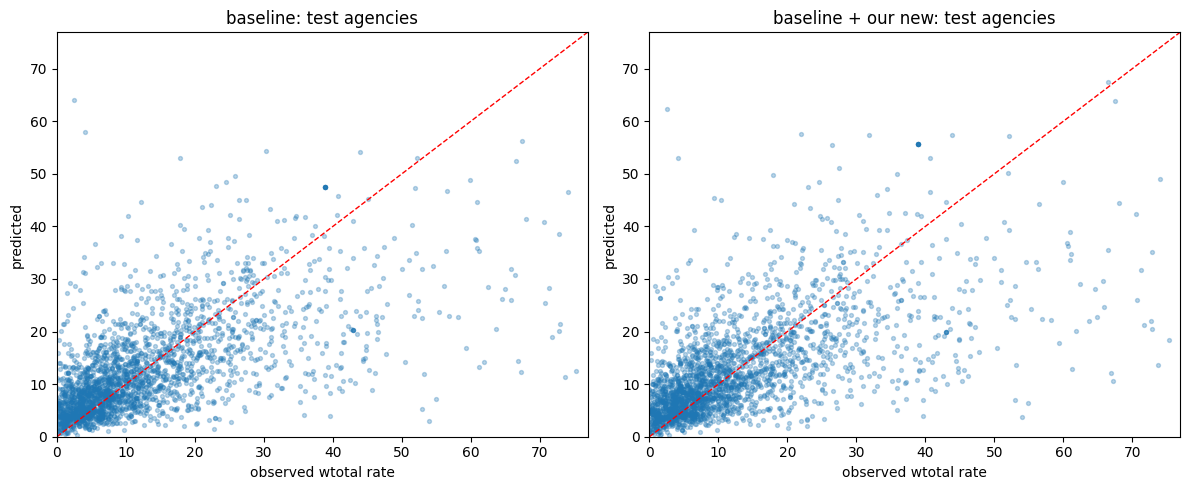

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, pred) in zip(axes, [("baseline", pred_base), ("baseline + our new", pred_aug)]):
    obs = test_df["wtotal_pt_m"].values
    ax.scatter(obs, pred, s=8, alpha=0.3)
    lim = [0, np.nanpercentile(obs, 99)]
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("observed wtotal rate"); ax.set_ylabel("predicted")
    ax.set_title(f"{label}: test agencies")
plt.tight_layout()

#### 6. Ablation on top of **our** model (add location/other features)

Starts from **our** predictor set (test R²≈0.22) and appends extra `ct_muni_df` columns to see
their marginal impact on fit — *not* on top of the baseline. Non-demographic, location-specific
region indicators (`encentral`, `midatlantic`, `southatlantic`) are the first experiment.

**Tweak me:** edit the `experiments` dict — each entry is a label → list of extra columns from
`model_df`. Add any variables (region flags, single baseline predictors, interactions you
precompute into `model_df`, …) to compare their lift. Added columns are train-median filled so
sparsely-populated variables won't break the fit; the train/test split is held fixed.

In [35]:
# EDIT THIS: label -> list of extra columns from model_df to append to our_predictors
experiments = {
    "ours only": [],
    "+ region (encentral, midatlantic, southatlantic)": ["encentral", "midatlantic", "southatlantic"],
}

def fit_ours_plus(extra):
    preds = our_predictors + [c for c in extra if c not in our_predictors]
    missing = [c for c in preds if c not in model_df.columns]
    if missing:
        raise KeyError(f"columns not in model_df: {missing}")
    med = train_df[preds].median()
    Xtr = train_df[preds].fillna(med); Xte = test_df[preds].fillna(med)
    scaler = StandardScaler().fit(Xtr)
    ytr, yte = train_df["wtotal_pt_m"].values, test_df["wtotal_pt_m"].values
    wtr, wte = train_df["population_m"].values, test_df["population_m"].values
    model = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
    model.fit(scaler.transform(Xtr), ytr, sample_weight=wtr)
    pte = model.predict(scaler.transform(Xte))
    r2 = r2_score(yte, pte, sample_weight=wte)
    return dict(n_predictors=len(preds), R2_test=round(r2, 3),
                adjR2_test=round(adjusted_r2(r2, len(yte), len(preds)), 3),
                MAE_test=round(mean_absolute_error(yte, pte, sample_weight=wte), 3)), pte

rows, preds_store = {}, {}
for label, extra in experiments.items():
    rows[label], preds_store[label] = fit_ours_plus(extra)
ablation = pd.DataFrame(rows).T
base_r2 = ablation.loc["ours only", "R2_test"]
ablation["dR2_vs_ours"] = (ablation["R2_test"] - base_r2).round(3)
ablation

,n_predictors,R2_test,adjR2_test,MAE_test,dR2_vs_ours
ours only,21.0,0.364,0.358,8.599,0.000
"+ region (encentral, midatlantic, southatlantic)",24.0,0.450,0.444,8.095,0.086


#### 7. Stepwise (forward) feature selection

A legitimate selection pass we want on our set anyway, plus an experiment layering baseline
features on top.

**Method.** Greedy forward selection where each candidate set is scored by **population-weighted
5-fold CV R² on the *training* agencies** (selection never touches the test set). A feature is
added only if it improves CV R² by more than `TOL`; we stop when none do. The held-out **test
adjusted R²** is reported alongside as an honest validation curve (not used for selection).

- **Phase 1 — our model:** forward-select from `our_predictors`. This is the parsimonious
  subset of our own features.
- **Phase 2 — baseline add-ons:** holding the Phase-1 set fixed, forward-add from the baseline
  `new_predictors`. Whatever gets picked (and its CV/test delta) is the incremental signal the
  existing model has that ours lacks.

In [36]:
from sklearn.model_selection import KFold

TOL = 0.001          # min CV-R² gain to keep adding a feature (tweak for more/less parsimony)
N_SPLITS = 5

def _weighted_cv_r2(preds, seed=0):
    if not preds:
        return float("-inf")
    X = train_df[preds].fillna(train_df[preds].median())
    y = train_df["wtotal_pt_m"].values
    w = train_df["population_m"].values
    oof = np.empty(len(y))
    for tr, va in KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(X):
        sc = StandardScaler().fit(X.iloc[tr])
        m = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
        m.fit(sc.transform(X.iloc[tr]), y[tr], sample_weight=w[tr])
        oof[va] = m.predict(sc.transform(X.iloc[va]))
    return r2_score(y, oof, sample_weight=w)

def _test_fit(preds):
    med = train_df[preds].median()
    Xtr, Xte = train_df[preds].fillna(med), test_df[preds].fillna(med)
    sc = StandardScaler().fit(Xtr)
    ytr, yte = train_df["wtotal_pt_m"].values, test_df["wtotal_pt_m"].values
    wtr, wte = train_df["population_m"].values, test_df["population_m"].values
    m = TransformedTargetRegressor(regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1)
    m.fit(sc.transform(Xtr), ytr, sample_weight=wtr)
    pte = m.predict(sc.transform(Xte))
    r2 = r2_score(yte, pte, sample_weight=wte)
    return dict(R2_test=round(r2, 3),
                adjR2_test=round(adjusted_r2(r2, len(yte), len(preds)), 3),
                MAE_test=round(mean_absolute_error(yte, pte, sample_weight=wte), 3))

def forward_select(pool, base=None, tol=TOL):
    selected = list(base or [])
    remaining = [c for c in pool if c not in selected]
    best = _weighted_cv_r2(selected) if selected else float("-inf")
    hist = []
    while remaining:
        score, feat = max(((_weighted_cv_r2(selected + [c]), c) for c in remaining),
                          key=lambda t: t[0])
        if score - best < tol:
            break
        selected.append(feat); remaining.remove(feat)
        t = _test_fit(selected)
        hist.append(dict(step=len(selected) - len(base or []), added=feat,
                         cv_R2=round(score, 4), d_cv=round(score - best, 4),
                         test_adjR2=t["adjR2_test"], test_MAE=t["MAE_test"]))
        best = score
    return selected, pd.DataFrame(hist)

**Phase 1 — forward selection on our own features.**

In [37]:
our_selected, hist1 = forward_select(our_predictors)
print(f"selected {len(our_selected)} of {len(our_predictors)} our-predictors:")
print(our_selected)
print("\n  full our-set   :", _test_fit(our_predictors))
print("  stepwise our-set:", _test_fit(our_selected))
hist1

selected 8 of 21 our-predictors:
['own_pct', 'vacant_pct_log', 'pop_est_5mile_log', 'pop_ch_1mile', 'roof_debris_pct_avg', 'unq_gas_stations_clips', 'lap_pct', 'vacant_pct_lag6_log']

  full our-set   : {'R2_test': 0.364, 'adjR2_test': 0.358, 'MAE_test': 8.599}
  stepwise our-set: {'R2_test': 0.238, 'adjR2_test': 0.236, 'MAE_test': 10.628}


,step,added,cv_R2,d_cv,test_adjR2,test_MAE
0,1,own_pct,0.1836,inf,-0.341,13.574
1,2,vacant_pct_log,0.3467,0.1630,0.238,10.602
2,3,pop_est_5mile_log,0.4433,0.0966,-0.032,12.323
3,4,pop_ch_1mile,0.4508,0.0075,0.002,12.163
4,5,roof_debris_pct_avg,0.4574,0.0066,-0.004,12.176
5,6,unq_gas_stations_clips,0.4611,0.0037,0.039,11.949
6,7,lap_pct,0.4656,0.0045,0.236,10.624
7,8,vacant_pct_lag6_log,0.4671,0.0015,0.236,10.628


**Phase 2 — forward-add baseline features on top of the Phase-1 set.**

In [38]:
combined, hist2 = forward_select(new_predictors, base=our_selected)
added = [c for c in combined if c not in our_selected]
print(f"baseline features added on top: {added}")
print("\n  stepwise our-set      :", _test_fit(our_selected))
print("  + baseline stepwise adds:", _test_fit(combined))
hist2

baseline features added on top: ['zusrpct_total_sc', 'zsqrt_pop_est_50mile', 'zgini_index', 'midatlantic', 'zmrpct_val_rm', 'zcol_pct', 'zlg10_dorms_pct', 'encentral', 'zlg10_seasonal_pct', 'zsqrt_vacant_pct', 'zlg10_jobs_5min']

  stepwise our-set      : {'R2_test': 0.238, 'adjR2_test': 0.236, 'MAE_test': 10.628}
  + baseline stepwise adds: {'R2_test': 0.62, 'adjR2_test': 0.617, 'MAE_test': 6.815}


,step,added,cv_R2,d_cv,test_adjR2,test_MAE
0,1,zusrpct_total_sc,0.5315,0.0644,0.228,10.493
1,2,zsqrt_pop_est_50mile,0.5585,0.0270,0.422,9.289
2,3,zgini_index,0.5831,0.0247,0.380,9.608
3,4,midatlantic,0.5961,0.0130,0.555,7.769
4,5,zmrpct_val_rm,0.6035,0.0073,0.572,7.374
5,6,zcol_pct,0.6094,0.0059,0.568,7.550
6,7,zlg10_dorms_pct,0.6143,0.0049,0.571,7.461
7,8,encentral,0.6180,0.0037,0.574,7.453
8,9,zlg10_seasonal_pct,0.6218,0.0038,0.584,7.305
9,10,zsqrt_vacant_pct,0.6365,0.0146,0.608,6.883


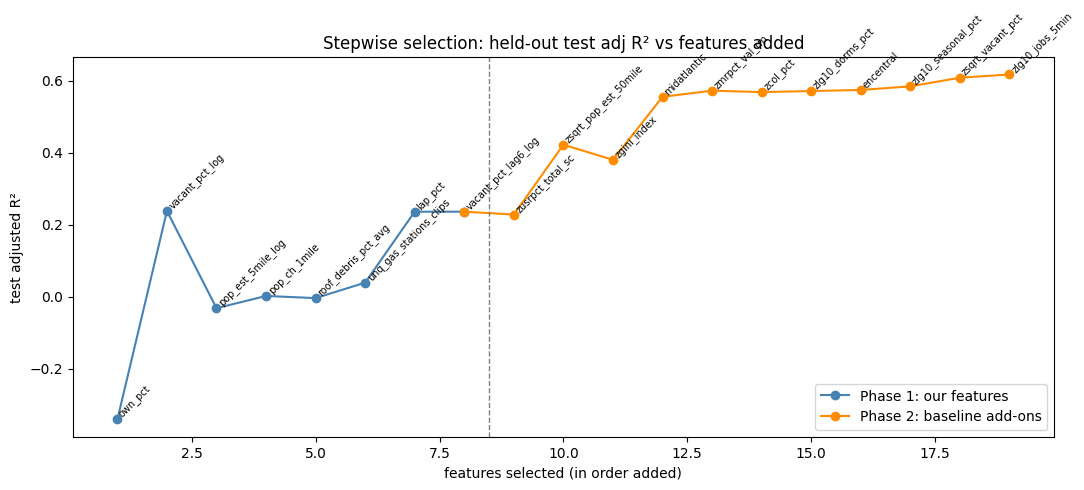

In [39]:
# validation curve: held-out test adjusted R² as features are added (phase 1 then phase 2)
p1 = hist1.assign(phase="our features")
p2 = hist2.assign(phase="baseline add-ons")
traj = pd.concat([p1, p2], ignore_index=True)
traj["k"] = range(1, len(traj) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
n1 = len(p1)
ax.plot(traj["k"][:n1], traj["test_adjR2"][:n1], "-o", color="steelblue", label="Phase 1: our features")
ax.plot(traj["k"][n1-1:], traj["test_adjR2"][n1-1:], "-o", color="darkorange", label="Phase 2: baseline add-ons")
for _, r in traj.iterrows():
    ax.annotate(r["added"], (r["k"], r["test_adjR2"]), rotation=45,
                fontsize=7, ha="left", va="bottom")
ax.axvline(n1 + 0.5, color="grey", ls="--", lw=1)
ax.set_xlabel("features selected (in order added)"); ax.set_ylabel("test adjusted R²")
ax.set_title("Stepwise selection: held-out test adj R² vs features added")
ax.legend(loc="lower right"); plt.tight_layout()